# Citi Bike — Where We Go From Here

This notebook is a **GPU-aware continuation notebook** for the v6 modeling work.

It does two jobs:

1. **Extract and summarize the results already embedded in v6** so the story is easy to explain.
2. **Turn those results into concrete next experiments** that move the project closer to the original goal: predicting bike/scooter availability, not just next-hour demand.

When RAPIDS is available in the runtime, the heavier random-forest experiments in this notebook use the **same explicit GPU path style as the v6 GPU rewrite**. If RAPIDS is unavailable, the notebook falls back to CPU automatically.

---

## The current state in one sentence

Your modeling pipeline is already strong enough to claim that **next-hour departures and arrivals are predictable at the busiest stations**, but the project is **not finished** because:

- the current evaluation is on only the **top 50 busiest stations**,
- the **capacity merge appears broken**,
- the utilization/availability proxy is currently **all NaN**, and
- the project goal is still **availability**, while the best current target is **next-hour demand**.


In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path
import io
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from IPython.display import Markdown, display

from sklearn.base import BaseEstimator, RegressorMixin, ClassifierMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression as SKLinearRegression
from sklearn.ensemble import (
    RandomForestRegressor as SKRandomForestRegressor,
    RandomForestClassifier as SKRandomForestClassifier,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)


def locate_existing_path(candidates):
    for path in candidates:
        path = Path(path)
        if path.exists():
            return path
    return None


SOURCE_NOTEBOOK_CANDIDATES = [
    Path("/content/CitiBike_2025_EDA_Modeling_v6_gpu_rewrite (1).ipynb"),
    Path("CitiBike_2025_EDA_Modeling_v6_gpu_rewrite.ipynb"),
    Path("CitiBike_2025_EDA_Modeling_v6.ipynb"),
    Path("/mnt/data/CitiBike_2025_EDA_Modeling_v6_gpu_rewrite (1).ipynb"),
    Path("/mnt/data/CitiBike_2025_EDA_Modeling_v6_gpu_rewrite.ipynb"),
    Path("/mnt/data/CitiBike_2025_EDA_Modeling_v6.ipynb"),
]
FEATURE_CACHE_CANDIDATES = [
    Path("outputs/feature_df_model_ready_2025_v6.parquet"),
    Path("/content/feature_df_model_ready_2025_v6.parquet"),
    Path("outputs/feature_df_model_ready_2025_v5.parquet"),
    Path("feature_df_model_ready_2025_v5.parquet"),
    Path("/mnt/data/outputs/feature_df_model_ready_2025_v6.parquet"),
    Path("/mnt/data/feature_df_model_ready_2025_v6.parquet"),
    Path("/mnt/data/outputs/feature_df_model_ready_2025_v5.parquet"),
    Path("/mnt/data/feature_df_model_ready_2025_v5.parquet"),
]
STATION_LOOKUP_CANDIDATES = [
    Path("/content/station_lookup.csv"),
    Path("/mnt/data/station_lookup.csv"),
]
GBFS_STATION_INFO_URL = "https://gbfs.lyft.com/gbfs/2.3/bkn/en/station_information.json"

USE_GPU_EXPERIMENTS = True
GPU_NUMERIC_DTYPE = np.float32


def make_dense_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=GPU_NUMERIC_DTYPE)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False, dtype=GPU_NUMERIC_DTYPE)


GPU_CONTEXT = {
    "enabled": False,
    "device_count": 0,
    "reason": "RAPIDS imports not attempted.",
    "cp": None,
    "cudf": None,
    "GPULinearRegression": None,
    "GPURandomForestRegressor": None,
    "GPURandomForestClassifier": None,
}

try:
    import cupy as cp
    import cudf
    import cuml
    from cuml.ensemble import RandomForestRegressor as GPURandomForestRegressor
    from cuml.ensemble import RandomForestClassifier as GPURandomForestClassifier
    from cuml.linear_model import LinearRegression as GPULinearRegression

    device_count = int(cp.cuda.runtime.getDeviceCount())
    GPU_CONTEXT.update({
        "enabled": device_count > 0,
        "device_count": device_count,
        "reason": "RAPIDS imports succeeded.",
        "cp": cp,
        "cudf": cudf,
        "GPULinearRegression": GPULinearRegression,
        "GPURandomForestRegressor": GPURandomForestRegressor,
        "GPURandomForestClassifier": GPURandomForestClassifier,
    })
except Exception as exc:
    GPU_CONTEXT["reason"] = f"RAPIDS imports unavailable: {exc}"

print("GPU acceleration available:", GPU_CONTEXT["enabled"])
print("GPU devices detected:", GPU_CONTEXT["device_count"])
print("Runtime note:", GPU_CONTEXT["reason"])
if not GPU_CONTEXT["enabled"]:
    print("Notebook will fall back to pandas/scikit-learn unless RAPIDS is installed in this runtime.")


GPU acceleration available: True
GPU devices detected: 1
Runtime note: RAPIDS imports succeeded.


In [3]:
import shutil

src = "/content/drive/MyDrive/feature_df_model_ready_2025_v6.parquet"
dst = "/content/feature_df_model_ready_2025_v6.parquet"
shutil.copy2(src, dst)

'/content/feature_df_model_ready_2025_v6.parquet'

In [4]:
from pathlib import Path
import os

content = Path("/content")

matches = sorted(content.glob("feature_df_model_ready_2025_v6*"))
print("Matching files:")
for p in matches:
    try:
        size = p.stat().st_size
        with open(p, "rb") as f:
            head = f.read(4)
            f.seek(-4, 2)
            tail = f.read(4)
        print(f"{p.name:45} size={size:,} head={head} tail={tail}")
    except Exception as e:
        print(f"{p.name:45} ERROR: {e}")

print("\nResolved path check:")
target = Path("/content/feature_df_model_ready_2025_v6.parquet")
print("exists:", target.exists())
if target.exists():
    print("realpath:", os.path.realpath(target))
    print("size:", target.stat().st_size)

Matching files:
feature_df_model_ready_2025_v6.parquet        size=459,915,241 head=b'PAR1' tail=b'PAR1'

Resolved path check:
exists: True
realpath: /content/feature_df_model_ready_2025_v6.parquet
size: 459915241



## 1) Pull the key results out of the v6 notebook

The nice part about notebooks is that their outputs are stored in the `.ipynb` file. This cell reads those stored outputs directly, so we can reuse your existing results even if the cached parquet files are not available yet.


In [5]:
def load_notebook(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Notebook not found: {path}")
    return json.loads(path.read_text(encoding="utf-8"))


def cell_source(cell):
    return "".join(cell.get("source", []))


def first_stream_text(cell):
    texts = []
    for out in cell.get("outputs", []):
        if out.get("output_type") == "stream":
            texts.append("".join(out.get("text", [])))
    return "\n".join(texts)


def html_tables_from_cell(cell):
    tables = []
    for out in cell.get("outputs", []):
        if out.get("output_type") in {"display_data", "execute_result"}:
            data = out.get("data", {})
            html = data.get("text/html")
            if html:
                html_str = "".join(html) if isinstance(html, list) else html
                try:
                    parsed = pd.read_html(io.StringIO(html_str))
                    tables.extend(parsed)
                except Exception:
                    pass
    return tables


def find_cell(nb, needle: str):
    for cell in nb["cells"]:
        if needle in cell_source(cell):
            return cell
    raise KeyError(f"Could not find cell containing: {needle}")


SOURCE_NOTEBOOK = locate_existing_path(SOURCE_NOTEBOOK_CANDIDATES)
if SOURCE_NOTEBOOK is None:
    raise FileNotFoundError(
        "Could not find a source v6 notebook. Checked: "
        + ", ".join(str(p) for p in SOURCE_NOTEBOOK_CANDIDATES)
    )

print("Reading stored outputs from:", SOURCE_NOTEBOOK)
nb_json = load_notebook(SOURCE_NOTEBOOK)

config_cell = find_cell(nb_json, "TOP_N_STATIONS_FOR_MODEL =")
agg_cell = find_cell(nb_json, "station_hour_cache = OUTPUT_DIR")
util_cell = find_cell(nb_json, "def add_capacity_utilization")
summary_cell = find_cell(nb_json, "target_summary = pd.DataFrame(summary_rows)")
primary_results_cell = find_cell(nb_json, 'print("Primary target:", PRIMARY_TARGET)')
weather_error_cell = find_cell(nb_json, 'weather_summary = weather_error.groupby("is_precipitating"')
importance_cell = find_cell(nb_json, 'importance_df = extract_feature_importance')
residual_cell = find_cell(nb_json, 'Residual mean:')

config_text = cell_source(config_cell)
agg_text = first_stream_text(agg_cell)
util_text = first_stream_text(util_cell)
residual_text = first_stream_text(residual_cell)

summary_tables = html_tables_from_cell(summary_cell)
primary_tables = html_tables_from_cell(primary_results_cell)
weather_tables = html_tables_from_cell(weather_error_cell)
importance_tables = html_tables_from_cell(importance_cell)

results = {
    "top_n_stations": int(re.search(r"TOP_N_STATIONS_FOR_MODEL\s*=\s*(\d+)", config_text).group(1)),
    "agg_unique_stations": int(re.search(r"Unique stations:\s*(\d+)", agg_text).group(1)),
    "agg_rows": int(re.search(r"\((\d+),\s*6\)", agg_text).group(1)),
    "capacity_matched": int(re.search(r"Capacity matched:\s*(\d+)/(\d+)", agg_text).group(1)),
    "capacity_total": int(re.search(r"Capacity matched:\s*(\d+)/(\d+)", agg_text).group(2)),
    "target_summary": summary_tables[0] if summary_tables else None,
    "primary_validation": primary_tables[0] if len(primary_tables) >= 1 else None,
    "primary_test": primary_tables[1] if len(primary_tables) >= 2 else None,
    "weather_error": weather_tables[0] if weather_tables else None,
    "feature_importance": importance_tables[0] if importance_tables else None,
    "residual_text": residual_text,
    "util_text": util_text,
}

results["target_summary"]


Reading stored outputs from: /content/CitiBike_2025_EDA_Modeling_v6_gpu_rewrite (1).ipynb


,Unnamed: 0,target,best_validation_model,validation_rmse,validation_mae,validation_r2,final_test_rmse,final_test_mae,final_test_r2
0,0,departures_next_hour,Random Forest (deeper),6.036261,4.116681,0.773836,4.662635,3.316405,0.642685
1,1,arrivals_next_hour,Random Forest (deeper),6.243425,4.182187,0.766557,5.013535,3.427978,0.608976
2,2,net_flow_next_hour,Random Forest (deeper),6.266928,4.218616,0.419668,4.750213,3.232679,0.320231



## 2) What the current notebook already proves

These are the strongest claims you can already make from v6:

- **Random Forest (deeper)** is the best model for all three current targets.
- **Departures** and **arrivals** are much easier to predict than **net flow**.
- The strongest signals are mostly **recent activity** and **time-of-day / cyclic time features**.
- Weather appears to matter, but it looks **secondary** compared with lagged demand and time structure.
- The current system is best described as a **next-hour demand model for busy stations**, not yet a true citywide availability model.


In [6]:

print(f"Top-N stations used for modeling: {results['top_n_stations']}")
print(f"Unique stations in aggregated station-hour table: {results['agg_unique_stations']}")
print(f"Station-hour rows in aggregation: {results['agg_rows']:,}")
print(f"Capacity matched during merge: {results['capacity_matched']}/{results['capacity_total']}")
print()

if results["target_summary"] is not None:
    display(Markdown("### Current best-model summary"))
    display(results["target_summary"])

if results["primary_test"] is not None:
    display(Markdown("### Primary target test-set comparison"))
    display(results["primary_test"])

if results["feature_importance"] is not None:
    display(Markdown("### Top feature importances for the primary target"))
    display(results["feature_importance"].head(15))

if results["weather_error"] is not None:
    display(Markdown("### Dry vs precipitating error slice"))
    display(results["weather_error"])

print("Residual diagnostics from v6:")
print(results["residual_text"].strip())
print()
print("Capacity / utilization text from v6:")
print(results["util_text"].strip())


Top-N stations used for modeling: 150
Unique stations in aggregated station-hour table: 2428
Station-hour rows in aggregation: 11,966,828
Capacity matched during merge: 0/2428



### Current best-model summary

,Unnamed: 0,target,best_validation_model,validation_rmse,validation_mae,validation_r2,final_test_rmse,final_test_mae,final_test_r2
0,0,departures_next_hour,Random Forest (deeper),6.036261,4.116681,0.773836,4.662635,3.316405,0.642685
1,1,arrivals_next_hour,Random Forest (deeper),6.243425,4.182187,0.766557,5.013535,3.427978,0.608976
2,2,net_flow_next_hour,Random Forest (deeper),6.266928,4.218616,0.419668,4.750213,3.232679,0.320231


### Primary target test-set comparison

,Unnamed: 0,rmse,mae,r2,target,model,split
0,0,4.662635,3.316405,0.642685,departures_next_hour,Random Forest (deeper),test
1,1,4.842126,3.453640,0.614646,departures_next_hour,Random Forest,test
2,2,7.451014,4.922430,0.087529,departures_next_hour,Naive baseline,test
3,3,110.090447,77.137533,-198.199081,departures_next_hour,Linear Regression,test


### Top feature importances for the primary target

,Unnamed: 0,feature,importance
0,0,total_activity_lag_1,0.331869
1,1,hour_cos,0.182160
2,2,hour_of_day,0.091125
3,3,departures_roll_24,0.068033
4,4,arrivals_roll_24,0.039473
5,5,is_commute_peak,0.038261
6,6,total_activity_roll_24,0.027873
7,7,is_weekend,0.017665
8,8,lat,0.015758
9,9,utilization_ratio_lag_1,0.013321


### Dry vs precipitating error slice

,Unnamed: 0,is_precipitating,abs_error
0,0,0,3.294127
1,1,1,3.467500


Residual diagnostics from v6:
Residual mean: -1.229  |  std: 4.498  |  skew: 0.360

Capacity / utilization text from v6:
Utilization ratio stats:



## 3) The biggest gaps to close next

### Gap A — Coverage
The current model uses only the **top 50 busiest stations**, while the aggregation contains **2,428 stations**. That is a perfectly reasonable modeling choice, but it means the current scores are **not citywide scores yet**.

### Gap B — Capacity / utilization
The capacity merge reports **0 / 2,428 stations matched**, and the utilization summary shows **all NaN**. That means the notebook currently cannot support the availability-proxy part of the story yet.

### Gap C — Task mismatch
Your original project framing is about **bike availability**, but your strongest result so far is on **departures/arrivals next hour**. That is still a good result, but the final project should explicitly bridge from demand prediction to an availability or shortage-risk task.

### Gap D — Evaluation story
The next report will be much stronger if you can show:

1. how accuracy changes as you move from top 50 to top 100 / 250 / all stations,
2. which feature families actually help,
3. where the model fails most often, and
4. how the model supports a real operational decision like **shortage alerts** or **rebalancing**.


## 4) Experiment 1 - Fix the capacity join with a multi-pass merge

This version replaces the single-key audit with a more reliable merge strategy:

1. join historical station codes to GBFS `short_name`
2. fall back to GBFS `station_id`
3. fall back to normalized station name
4. fall back to normalized name plus rounded latitude/longitude

That makes the notebook much more robust when Citi Bike trip history and the live GBFS feed use different key formats.

**Important upstream note:** if your cleaning notebook currently drops `start_station_id` and `end_station_id`, keep them. The cleanest capacity join usually comes from preserving station IDs or short codes instead of relying only on names.


In [7]:
import unicodedata


def _to_ascii_text(x):
    if pd.isna(x):
        return pd.NA
    x = str(x).strip()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("ascii")
    return x


def normalize_station_key(series: pd.Series) -> pd.Series:
    s = pd.Series(series, dtype="string")
    s = s.astype("string").str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.str.replace(r"\s+", "", regex=True)
    return s


def normalize_station_name(series: pd.Series) -> pd.Series:
    s = pd.Series(series).map(_to_ascii_text).astype("string").str.lower()
    s = s.str.replace("&", " and ", regex=False)
    s = s.str.replace(r"[^a-z0-9]+", " ", regex=True)
    s = s.str.replace(r"\bavenue\b", "ave", regex=True)
    s = s.str.replace(r"\bstreet\b", "st", regex=True)
    s = s.str.replace(r"\bplace\b", "pl", regex=True)
    s = s.str.replace(r"\broad\b", "rd", regex=True)
    s = s.str.replace(r"\bparkway\b", "pkwy", regex=True)
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s


def unwrap_gbfs_name(x):
    if isinstance(x, list):
        parts = []
        for item in x:
            if isinstance(item, dict):
                txt = item.get("text")
                if txt:
                    parts.append(str(txt))
            elif item is not None:
                parts.append(str(item))
        return " ".join(parts) if parts else None
    return x


def fetch_gbfs_capacity(url: str = GBFS_STATION_INFO_URL) -> pd.DataFrame:
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    stations = response.json()["data"]["stations"]
    gbfs = pd.DataFrame(stations).copy()

    if "name" in gbfs.columns:
        gbfs["name"] = gbfs["name"].map(unwrap_gbfs_name)

    keep_cols = [c for c in ["station_id", "short_name", "name", "capacity", "lat", "lon"] if c in gbfs.columns]
    gbfs = gbfs[keep_cols].copy()

    gbfs["station_id_norm"] = normalize_station_key(gbfs.get("station_id"))
    gbfs["short_name_norm"] = normalize_station_key(gbfs.get("short_name"))
    gbfs["name_norm"] = normalize_station_name(gbfs.get("name"))
    gbfs["lat_r4"] = pd.to_numeric(gbfs.get("lat"), errors="coerce").round(4)
    gbfs["lon_r4"] = pd.to_numeric(gbfs.get("lon"), errors="coerce").round(4)
    gbfs["capacity"] = pd.to_numeric(gbfs.get("capacity"), errors="coerce")

    return gbfs


def first_capacity_map(df: pd.DataFrame, key_cols):
    tmp = df.dropna(subset=key_cols + ["capacity"]).copy()
    tmp = tmp.groupby(key_cols, as_index=False)["capacity"].median()
    return tmp


def attach_capacity_to_station_lookup(station_lookup: pd.DataFrame) -> pd.DataFrame:
    sl = station_lookup.copy()
    sl.columns = sl.columns.str.strip().str.lower()
    gbfs = fetch_gbfs_capacity()

    code_col = next((c for c in ["station_id", "short_name", "station_code", "station_key"] if c in sl.columns), None)
    name_col = next((c for c in ["station_name", "name", "station_key"] if c in sl.columns), None)
    lat_col = next((c for c in ["lat", "latitude"] if c in sl.columns), None)
    lng_col = next((c for c in ["lng", "lon", "longitude"] if c in sl.columns), None)

    sl["code_norm"] = normalize_station_key(sl[code_col]) if code_col else pd.Series(pd.NA, index=sl.index, dtype="string")
    sl["name_norm"] = normalize_station_name(sl[name_col]) if name_col else pd.Series(pd.NA, index=sl.index, dtype="string")
    sl["lat_r4"] = pd.to_numeric(sl[lat_col], errors="coerce").round(4) if lat_col else np.nan
    sl["lng_r4"] = pd.to_numeric(sl[lng_col], errors="coerce").round(4) if lng_col else np.nan

    sl["capacity"] = np.nan
    sl["capacity_source"] = pd.NA

    short_map = first_capacity_map(gbfs, ["short_name_norm"]).rename(columns={"short_name_norm": "code_norm", "capacity": "capacity_short"})
    sl = sl.merge(short_map, on="code_norm", how="left")
    m = sl["capacity"].isna() & sl["capacity_short"].notna()
    sl.loc[m, "capacity"] = sl.loc[m, "capacity_short"]
    sl.loc[m, "capacity_source"] = "short_name"
    sl = sl.drop(columns=["capacity_short"])

    id_map = first_capacity_map(gbfs, ["station_id_norm"]).rename(columns={"station_id_norm": "code_norm", "capacity": "capacity_id"})
    sl = sl.merge(id_map, on="code_norm", how="left")
    m = sl["capacity"].isna() & sl["capacity_id"].notna()
    sl.loc[m, "capacity"] = sl.loc[m, "capacity_id"]
    sl.loc[m, "capacity_source"] = "station_id"
    sl = sl.drop(columns=["capacity_id"])

    name_map = first_capacity_map(gbfs, ["name_norm"]).rename(columns={"capacity": "capacity_name"})
    sl = sl.merge(name_map, on="name_norm", how="left")
    m = sl["capacity"].isna() & sl["capacity_name"].notna()
    sl.loc[m, "capacity"] = sl.loc[m, "capacity_name"]
    sl.loc[m, "capacity_source"] = "name"
    sl = sl.drop(columns=["capacity_name"])

    if "lat_r4" in sl.columns and "lng_r4" in sl.columns:
        name_geo_map = first_capacity_map(gbfs, ["name_norm", "lat_r4", "lon_r4"]).rename(
            columns={"lon_r4": "lng_r4", "capacity": "capacity_name_geo"}
        )
        sl = sl.merge(name_geo_map, on=["name_norm", "lat_r4", "lng_r4"], how="left")
        m = sl["capacity"].isna() & sl["capacity_name_geo"].notna()
        sl.loc[m, "capacity"] = sl.loc[m, "capacity_name_geo"]
        sl.loc[m, "capacity_source"] = "name+geo"
        sl = sl.drop(columns=["capacity_name_geo"])

    return sl


def add_capacity_features_to_feature_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "capacity" in out.columns:
        out["capacity"] = pd.to_numeric(out["capacity"], errors="coerce")
    else:
        out["capacity"] = np.nan

    out["is_active_station"] = out["capacity"].notna().astype(int)

    needed = {"station_key", "hour", "net_flow", "capacity"}
    if needed.issubset(out.columns):
        out = out.sort_values(["station_key", "hour"]).reset_index(drop=True)
        out["initial_bikes"] = out["capacity"] * 0.50
        out["cumulative_net_flow"] = out.groupby("station_key", observed=True)["net_flow"].cumsum()
        out["bikes_available_proxy"] = (out["initial_bikes"] + out["cumulative_net_flow"]).clip(lower=0)
        out["bikes_available_proxy"] = np.minimum(out["bikes_available_proxy"], out["capacity"])
        out["utilization_ratio_proxy"] = out["bikes_available_proxy"] / out["capacity"].replace(0, np.nan)
        out["utilization_ratio_lag_1"] = out.groupby("station_key", observed=True)["utilization_ratio_proxy"].shift(1)
    else:
        if "utilization_ratio_lag_1" not in out.columns:
            out["utilization_ratio_lag_1"] = np.nan

    return out


station_lookup_path = locate_existing_path(STATION_LOOKUP_CANDIDATES)
station_lookup_with_capacity = None

if station_lookup_path is None:
    print("station_lookup.csv not found. Add it beside this notebook to run the capacity fix.")
else:
    station_lookup_raw = pd.read_csv(station_lookup_path)
    station_lookup_with_capacity = attach_capacity_to_station_lookup(station_lookup_raw)

    display(
        station_lookup_with_capacity[[c for c in [
            "station_id", "short_name", "station_name", "name", "capacity", "capacity_source"
        ] if c in station_lookup_with_capacity.columns]].head(10)
    )

    matched = int(station_lookup_with_capacity["capacity"].notna().sum())
    total = int(len(station_lookup_with_capacity))
    print(f"Capacity matched: {matched} / {total}")
    print(station_lookup_with_capacity["capacity_source"].value_counts(dropna=False))

    unmatched_cols = [c for c in ["station_id", "short_name", "station_name", "name", "lat", "lng", "capacity_source"] if c in station_lookup_with_capacity.columns]
    unmatched_preview = station_lookup_with_capacity.loc[
        station_lookup_with_capacity["capacity"].isna(), unmatched_cols
    ].head(10)
    if len(unmatched_preview) > 0:
        display(Markdown("### Sample unmatched stations after all merge passes"))
        display(unmatched_preview)


,station_id,station_name,capacity,capacity_source
0,1234.56,Morgan HCT Charging,NaN,<NA>
1,190 Morgan,190 Morgan,NaN,<NA>
2,1964.01,101 St & Fort Hamilton Pkwy,12.0,short_name
3,2009.04,Shore Rd & 4 Ave,12.0,short_name
4,2042.01,4 Ave & 99 St,16.0,short_name
5,2086.07,99 St & 3 Ave,14.0,short_name
6,2118.13,Fort Hamilton Pkwy & 95 St,16.0,short_name
7,2127.03,Shore Rd & 97 St,12.0,short_name
8,2158.08,4 Ave & 94 St,23.0,short_name
9,2190.08,Fort Hamilton Pkwy & 92 St,16.0,short_name


Capacity matched: 2389 / 2428
capacity_source
short_name    2284
name           105
<NA>            39
Name: count, dtype: int64


### Sample unmatched stations after all merge passes

,station_id,station_name,lat,lng,capacity_source
0,1234.56,Morgan HCT Charging,40.708948,-73.932777,<NA>
1,190 Morgan,190 Morgan,40.711072,-73.932096,<NA>
98,3138.09,58 St & 2 Ave,40.644512,-74.021506,<NA>
186,3460.06,2 Ave & 37 St,40.656240,-74.009330,<NA>
413,4199.13,Carlton Ave & St Marks Ave,40.679119,-73.971763,<NA>
525,4488.08,Court St & State St,40.690238,-73.992031,<NA>
581,4645.09,Hicks St & Montague St,40.695128,-73.995951,<NA>
640,4801.04,Melrose St & Broadway,40.697481,-73.935877,<NA>
704,4956.02,Humboldt St & Varet St,40.703172,-73.940636,<NA>
857,5329.03,West St & Chambers St,40.717548,-74.013221,<NA>



## 5) Load the cached feature table if it exists

The next experiments are easiest if you already have the cached feature parquet from v6:

`outputs/feature_df_model_ready_2025_v6.parquet`

If it is not found, this notebook still gives you the roadmap and code skeletons, but the modeling cells will skip execution.


In [8]:

feature_df_path = locate_existing_path(FEATURE_CACHE_CANDIDATES)
feature_df = None

if feature_df_path is None:
    print("feature_df cache not found. Re-run v6 locally until it saves outputs/feature_df_model_ready_2025_v6.parquet, then come back here.")
else:
    print("Loading feature_df from:", feature_df_path)
    feature_df = pd.read_parquet(feature_df_path)
    if "station_key" in feature_df.columns:
        feature_df["station_key"] = feature_df["station_key"].astype("category")
    print(feature_df.shape)
    display(feature_df.head())


Loading feature_df from: /content/feature_df_model_ready_2025_v6.parquet
(11966828, 66)


,station_key,hour,departures,arrivals,net_flow,total_activity,station_name,lat,lng,capacity,is_active_station,location_id,temperature_f,precipitation_in,rain_in,snowfall_in,snow_depth_ft,wind_speed_mph,soil_temperature_0_to_7cm (°F),soil_temperature_7_to_28cm (°F),relative_humidity_pct,dew_point_f,apparent_temperature_f,wind_gusts_mph,wind_direction_deg,hour_of_day,day_of_week,month,is_weekend,is_rush_hour,is_commute_peak,is_overnight,hour_sin,hour_cos,dow_sin,dow_cos,is_holiday,is_precipitating,heavy_precip_flag,is_raining,is_snowing,departures_lag_1,departures_lag_2,departures_lag_24,departures_roll_3,departures_roll_24,arrivals_lag_1,arrivals_lag_2,arrivals_lag_24,arrivals_roll_3,arrivals_roll_24,net_flow_lag_1,net_flow_lag_2,net_flow_lag_24,net_flow_roll_3,net_flow_roll_24,total_activity_lag_1,total_activity_lag_2,total_activity_lag_24,total_activity_roll_3,total_activity_roll_24,departures_next_hour,arrivals_next_hour,net_flow_next_hour,utilization_ratio,utilization_ratio_lag_1
0,1234.56,2025-06-18 22:00:00,0,1,1,1,Morgan HCT Charging,40.708948,-73.932777,NaN,0,1.0,70.2,0.004,0.004,0.0,0.0,0.8,72.5,69.8,100.0,70.1,77.8,5.8,214.0,22,2,6,0,0,0,0,-5.000000e-01,0.866025,0.974928,-0.222521,0,1,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,NaN,NaN
1,1234.56,2025-06-18 23:00:00,1,1,0,2,Morgan HCT Charging,40.708948,-73.932777,NaN,0,3.0,71.4,0.004,0.004,0.0,0.0,2.7,72.5,69.4,98.0,71.0,78.8,7.6,195.0,23,2,6,0,0,0,0,-2.588190e-01,0.965926,0.974928,-0.222521,0,1,0,1,0,0.0,NaN,NaN,0.000000,0.000000,1.0,NaN,NaN,1.000000,1.000000,1.0,NaN,NaN,1.000000,1.0,1.0,NaN,NaN,1.000000,1.000000,1.0,0.0,-1.0,NaN,NaN
2,1234.56,2025-06-19 23:00:00,1,0,-1,1,Morgan HCT Charging,40.708948,-73.932777,NaN,0,0.0,73.0,0.000,0.000,0.0,0.0,10.6,74.5,73.6,83.0,67.5,75.2,23.3,234.0,23,3,6,0,0,0,0,-2.588190e-01,0.965926,0.433884,-0.900969,1,0,0,0,0,1.0,0.0,NaN,0.500000,0.500000,1.0,1.0,NaN,1.000000,1.000000,0.0,1.0,NaN,0.500000,0.5,2.0,1.0,NaN,1.500000,1.500000,1.0,1.0,0.0,NaN,NaN
3,1234.56,2025-06-20 09:00:00,1,1,0,2,Morgan HCT Charging,40.708948,-73.932777,NaN,0,3.0,72.6,0.000,0.000,0.0,0.0,11.3,71.7,71.2,55.0,55.5,69.6,26.8,284.0,9,4,6,0,1,1,0,7.071068e-01,-0.707107,-0.433884,-0.900969,0,0,0,0,0,1.0,1.0,NaN,0.666667,0.666667,0.0,1.0,NaN,0.666667,0.666667,-1.0,0.0,NaN,0.000000,0.0,1.0,2.0,NaN,1.333333,1.333333,1.0,1.0,0.0,NaN,NaN
4,1234.56,2025-06-20 12:00:00,1,1,0,2,Morgan HCT Charging,40.708948,-73.932777,NaN,0,2.0,79.3,0.000,0.000,0.0,0.0,11.2,78.9,72.3,46.0,56.8,79.9,27.7,286.0,12,4,6,0,0,0,0,1.224647e-16,-1.000000,-0.433884,-0.900969,0,0,0,0,0,1.0,1.0,NaN,1.000000,0.750000,1.0,0.0,NaN,0.666667,0.750000,0.0,-1.0,NaN,-0.333333,0.0,2.0,1.0,NaN,1.666667,1.500000,1.0,1.0,0.0,NaN,NaN


## 5A) Enrich the cached feature table with recovered capacities

If `feature_df` loads successfully and the capacity fix found matches in `station_lookup.csv`, this cell merges the recovered capacities onto the modeling table and rebuilds the proxy utilization fields needed by later experiments.


In [9]:
def enrich_feature_df_with_capacity(feature_df: pd.DataFrame, station_lookup_with_capacity: pd.DataFrame) -> pd.DataFrame:
    if feature_df is None:
        return feature_df
    if station_lookup_with_capacity is None:
        return feature_df
    if "station_key" not in feature_df.columns:
        print("feature_df has no station_key column; skipping capacity enrichment.")
        return feature_df

    feat = feature_df.copy()
    lookup = station_lookup_with_capacity.copy()
    lookup.columns = lookup.columns.str.strip().str.lower()

    if "station_key" not in lookup.columns:
        if "station_id" in lookup.columns:
            lookup["station_key"] = lookup["station_id"]
        elif "short_name" in lookup.columns:
            lookup["station_key"] = lookup["short_name"]
        elif "station_name" in lookup.columns:
            lookup["station_key"] = lookup["station_name"]
        elif "name" in lookup.columns:
            lookup["station_key"] = lookup["name"]
        else:
            print("station_lookup_with_capacity has no usable station key column; skipping enrichment.")
            return feature_df

    feat["station_key_merge"] = normalize_station_key(feat["station_key"])
    lookup["station_key_merge"] = normalize_station_key(lookup["station_key"])

    keep_cols = [c for c in ["station_key_merge", "capacity", "capacity_source", "station_name", "name", "lat", "lng"] if c in lookup.columns]
    keep_cols = list(dict.fromkeys(keep_cols))
    lookup_small = lookup[keep_cols].drop_duplicates(subset=["station_key_merge"])

    enriched = feat.merge(lookup_small, on="station_key_merge", how="left", suffixes=("", "_lookup"))

    if "capacity_lookup" in enriched.columns:
        if "capacity" in enriched.columns:
            enriched["capacity"] = pd.to_numeric(enriched["capacity"], errors="coerce")
            enriched["capacity_lookup"] = pd.to_numeric(enriched["capacity_lookup"], errors="coerce")
            enriched["capacity"] = enriched["capacity"].fillna(enriched["capacity_lookup"])
            enriched = enriched.drop(columns=["capacity_lookup"])
        else:
            enriched = enriched.rename(columns={"capacity_lookup": "capacity"})

    for col in ["lat", "lng"]:
        lookup_col = f"{col}_lookup"
        if lookup_col in enriched.columns:
            if col in enriched.columns:
                enriched[col] = pd.to_numeric(enriched[col], errors="coerce")
                enriched[lookup_col] = pd.to_numeric(enriched[lookup_col], errors="coerce")
                enriched[col] = enriched[col].fillna(enriched[lookup_col])
                enriched = enriched.drop(columns=[lookup_col])
            else:
                enriched = enriched.rename(columns={lookup_col: col})

    enriched = add_capacity_features_to_feature_df(enriched)
    enriched = enriched.drop(columns=["station_key_merge"], errors="ignore")
    return enriched


if feature_df is None:
    print("Skipping capacity enrichment because feature_df did not load.")
elif station_lookup_with_capacity is None:
    print("Skipping capacity enrichment because station_lookup.csv was not found or did not merge.")
else:
    capacity_before = 0
    if "capacity" in feature_df.columns:
        capacity_before = int(pd.to_numeric(feature_df["capacity"], errors="coerce").notna().sum())

    feature_df = enrich_feature_df_with_capacity(feature_df, station_lookup_with_capacity)

    capacity_after = int(pd.to_numeric(feature_df["capacity"], errors="coerce").notna().sum()) if "capacity" in feature_df.columns else 0
    print(f"Capacity non-null before enrichment: {capacity_before}")
    print(f"Capacity non-null after enrichment:  {capacity_after}")

    summary_cols = [c for c in [
        "station_key", "capacity", "capacity_source", "is_active_station", "utilization_ratio_lag_1"
    ] if c in feature_df.columns]
    if summary_cols:
        display(feature_df[summary_cols].head(10))


Capacity non-null before enrichment: 0
Capacity non-null after enrichment:  11874909


,station_key,capacity,capacity_source,is_active_station,utilization_ratio_lag_1
0,1234.56,NaN,<NA>,0,NaN
1,1234.56,NaN,<NA>,0,NaN
2,1234.56,NaN,<NA>,0,NaN
3,1234.56,NaN,<NA>,0,NaN
4,1234.56,NaN,<NA>,0,NaN
5,1234.56,NaN,<NA>,0,NaN
6,1234.56,NaN,<NA>,0,NaN
7,1234.56,NaN,<NA>,0,NaN
8,1234.56,NaN,<NA>,0,NaN
9,1234.56,NaN,<NA>,0,NaN


## 6) Experiment 2 — Coverage vs accuracy tradeoff

This is the cleanest way to answer a very important question:

> Are the good scores only true for the busiest stations, or do they hold up as we expand coverage?

We keep the current task (`departures_next_hour`) but vary the number of stations included.

When RAPIDS is available, this experiment uses the same **dense preprocessing + explicit GPU random forest** pattern as the v6 GPU rewrite.


In [10]:
def _to_numpy_host(x):
    if x is None:
        return None

    cp = GPU_CONTEXT.get("cp", None)
    if cp is not None:
        try:
            return cp.asnumpy(x)
        except Exception:
            pass

    if hasattr(x, "get"):
        try:
            return x.get()
        except Exception:
            pass

    if hasattr(x, "to_numpy"):
        try:
            return x.to_numpy()
        except Exception:
            pass

    return np.asarray(x)


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mse = mean_squared_error(y_true, y_pred)
    return {
        "rmse": float(np.sqrt(mse)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }


def chronological_split(model_df):
    model_df = model_df.sort_values("hour").reset_index(drop=True)
    unique_hours = np.sort(model_df["hour"].unique())
    train_idx = max(1, int(len(unique_hours) * 0.70))
    valid_idx = max(train_idx + 1, int(len(unique_hours) * 0.85))
    valid_idx = min(valid_idx, len(unique_hours) - 1)

    train_cutoff = unique_hours[train_idx]
    valid_cutoff = unique_hours[valid_idx]

    train_df = model_df.loc[model_df["hour"] < train_cutoff].copy()
    valid_df = model_df.loc[(model_df["hour"] >= train_cutoff) & (model_df["hour"] < valid_cutoff)].copy()
    test_df = model_df.loc[model_df["hour"] >= valid_cutoff].copy()
    return train_df, valid_df, test_df


def busiest_station_keys(df, top_n=50):
    return (
        df.groupby("station_key", observed=True)["total_activity"]
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )


def split_feature_types(feature_cols, categorical_cols=("station_key", "station_cluster")):
    categorical_features = [c for c in categorical_cols if c in feature_cols]
    numeric_features = [c for c in feature_cols if c not in categorical_features]
    return numeric_features, categorical_features


class DenseTabularPreprocessor:
    def __init__(self, numeric_features, categorical_features):
        self.numeric_features = list(numeric_features)
        self.categorical_features = list(categorical_features)
        self.num_imputer = SimpleImputer(strategy="median")
        self.cat_imputer = SimpleImputer(strategy="most_frequent")
        self.onehot = make_dense_onehot_encoder()
        self.feature_names_out_ = None

    def fit(self, X):
        feature_names = []

        if self.numeric_features:
            num_df = X[self.numeric_features].apply(pd.to_numeric, errors="coerce")
            self.num_imputer.fit(num_df)
            feature_names.extend(self.numeric_features)

        if self.categorical_features:
            cat_df = X[self.categorical_features].astype("string")
            cat_filled = self.cat_imputer.fit_transform(cat_df)
            self.onehot.fit(cat_filled)
            feature_names.extend(self.onehot.get_feature_names_out(self.categorical_features).tolist())

        self.feature_names_out_ = np.asarray(feature_names, dtype=object)
        return self

    def transform(self, X):
        parts = []

        if self.numeric_features:
            num_df = X[self.numeric_features].apply(pd.to_numeric, errors="coerce")
            num_arr = self.num_imputer.transform(num_df).astype(GPU_NUMERIC_DTYPE, copy=False)
            parts.append(num_arr)

        if self.categorical_features:
            cat_df = X[self.categorical_features].astype("string")
            cat_filled = self.cat_imputer.transform(cat_df)
            cat_arr = self.onehot.transform(cat_filled).astype(GPU_NUMERIC_DTYPE, copy=False)
            parts.append(cat_arr)

        if not parts:
            return np.empty((len(X), 0), dtype=GPU_NUMERIC_DTYPE)

        return np.concatenate(parts, axis=1).astype(GPU_NUMERIC_DTYPE, copy=False)

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def get_feature_names_out(self):
        return self.feature_names_out_


class DenseGPUReadyRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, model_name, numeric_features, categorical_features, random_state=42, prefer_gpu=True):
        self.model_name = model_name
        self.numeric_features = list(numeric_features)
        self.categorical_features = list(categorical_features)
        self.random_state = random_state
        self.prefer_gpu = prefer_gpu

    def _use_gpu(self):
        if not (self.prefer_gpu and USE_GPU_EXPERIMENTS and GPU_CONTEXT["enabled"]):
            return False
        if self.model_name == "Linear Regression":
            return GPU_CONTEXT["GPULinearRegression"] is not None
        return GPU_CONTEXT["GPURandomForestRegressor"] is not None

    def _build_cpu_model(self):
        if self.model_name == "Linear Regression":
            return SKLinearRegression()
        if self.model_name == "Random Forest":
            return SKRandomForestRegressor(
                n_estimators=180,
                max_depth=16,
                min_samples_leaf=5,
                random_state=self.random_state,
                n_jobs=-1,
            )
        if self.model_name == "Random Forest (deeper)":
            return SKRandomForestRegressor(
                n_estimators=250,
                max_depth=18,
                min_samples_leaf=5,
                random_state=self.random_state,
                n_jobs=-1,
            )
        raise ValueError(f"Unknown model name: {self.model_name}")

    def _build_gpu_model(self):
        if self.model_name == "Linear Regression":
            return GPU_CONTEXT["GPULinearRegression"]()
        if self.model_name == "Random Forest":
            return GPU_CONTEXT["GPURandomForestRegressor"](
                n_estimators=180,
                max_depth=16,
                min_samples_leaf=5,
                random_state=self.random_state,
            )
        if self.model_name == "Random Forest (deeper)":
            return GPU_CONTEXT["GPURandomForestRegressor"](
                n_estimators=250,
                max_depth=18,
                min_samples_leaf=5,
                random_state=self.random_state,
            )
        raise ValueError(f"Unknown model name: {self.model_name}")

    def fit(self, X, y):
        self.preprocess_ = DenseTabularPreprocessor(self.numeric_features, self.categorical_features)
        X_dense = self.preprocess_.fit_transform(X)
        y_np = np.asarray(y, dtype=GPU_NUMERIC_DTYPE).reshape(-1)

        self.use_gpu_ = self._use_gpu()
        if self.use_gpu_:
            cp = GPU_CONTEXT["cp"]
            self.model_ = self._build_gpu_model()
            self.model_.fit(cp.asarray(X_dense), cp.asarray(y_np))
        else:
            self.model_ = self._build_cpu_model()
            self.model_.fit(X_dense, y_np)
        return self

    def predict(self, X):
        X_dense = self.preprocess_.transform(X)
        if getattr(self, "use_gpu_", False):
            cp = GPU_CONTEXT["cp"]
            preds = self.model_.predict(cp.asarray(X_dense))
            return cp.asnumpy(preds).reshape(-1)
        return np.asarray(self.model_.predict(X_dense)).reshape(-1)

    def get_feature_names_out(self):
        return self.preprocess_.get_feature_names_out()


class DenseGPUReadyClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, numeric_features, categorical_features, random_state=42, prefer_gpu=True):
        self.numeric_features = list(numeric_features)
        self.categorical_features = list(categorical_features)
        self.random_state = random_state
        self.prefer_gpu = prefer_gpu

    def _use_gpu(self):
        return bool(
            self.prefer_gpu
            and USE_GPU_EXPERIMENTS
            and GPU_CONTEXT["enabled"]
            and GPU_CONTEXT["GPURandomForestClassifier"] is not None
        )

    def _build_cpu_model(self):
        return SKRandomForestClassifier(
            n_estimators=180,
            max_depth=16,
            min_samples_leaf=5,
            random_state=self.random_state,
            n_jobs=-1,
        )

    def _build_gpu_model(self):
        return GPU_CONTEXT["GPURandomForestClassifier"](
            n_estimators=180,
            max_depth=16,
            min_samples_leaf=5,
            random_state=self.random_state,
        )

    def fit(self, X, y):
        self.preprocess_ = DenseTabularPreprocessor(self.numeric_features, self.categorical_features)
        X_dense = self.preprocess_.fit_transform(X)
        y_np = np.asarray(y, dtype=np.int32).reshape(-1)

        self.use_gpu_ = self._use_gpu()
        if self.use_gpu_:
            cp = GPU_CONTEXT["cp"]
            self.model_ = self._build_gpu_model()
            self.model_.fit(cp.asarray(X_dense), cp.asarray(y_np))
        else:
            self.model_ = self._build_cpu_model()
            self.model_.fit(X_dense, y_np)
        return self

    def predict(self, X):
        X_dense = self.preprocess_.transform(X)
        if getattr(self, "use_gpu_", False):
            cp = GPU_CONTEXT["cp"]
            preds = self.model_.predict(cp.asarray(X_dense))
            return cp.asnumpy(preds).reshape(-1)
        return np.asarray(self.model_.predict(X_dense)).reshape(-1)

    def predict_proba(self, X):
        X_dense = self.preprocess_.transform(X)
        if getattr(self, "use_gpu_", False):
            cp = GPU_CONTEXT["cp"]
            prob = self.model_.predict_proba(cp.asarray(X_dense))
            prob = cp.asnumpy(prob)
        else:
            prob = np.asarray(self.model_.predict_proba(X_dense))

        if prob.ndim == 1:
            prob = np.column_stack([1.0 - prob, prob])
        return prob

    def get_feature_names_out(self):
        return self.preprocess_.get_feature_names_out()


def build_reg_estimator(model_name, feature_cols, random_state=42):
    numeric_features, categorical_features = split_feature_types(feature_cols)
    return DenseGPUReadyRegressor(
        model_name=model_name,
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        random_state=random_state,
        prefer_gpu=True,
    )


def build_clf_estimator(feature_cols, random_state=42):
    numeric_features, categorical_features = split_feature_types(feature_cols)
    return DenseGPUReadyClassifier(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        random_state=random_state,
        prefer_gpu=True,
    )


def train_rf_regressor(train_df, valid_df, test_df, target_col, feature_cols, model_name="Random Forest (deeper)"):
    estimator = build_reg_estimator(model_name, feature_cols, random_state=42)

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    X_valid = valid_df[feature_cols]
    y_valid = valid_df[target_col]
    X_test = test_df[feature_cols]
    y_test = test_df[target_col]

    estimator.fit(X_train, y_train)
    valid_pred = estimator.predict(X_valid)
    test_pred = estimator.predict(X_test)

    valid_metrics = regression_metrics(y_valid, valid_pred)
    test_metrics = regression_metrics(y_test, test_pred)
    backend = "GPU" if getattr(estimator, "use_gpu_", False) else "CPU"
    return estimator, valid_pred, test_pred, valid_metrics, test_metrics, backend


,top_n_stations,n_rows,backend,valid_rmse,valid_r2,test_rmse,test_r2
0,25,203129,GPU,7.415308,0.822443,6.406146,0.632124
1,50,402373,GPU,6.842844,0.808588,6.054941,0.594386
2,100,799458,GPU,6.222595,0.791544,5.352511,0.588437
3,250,1952750,GPU,5.541193,0.763247,4.423867,0.598496


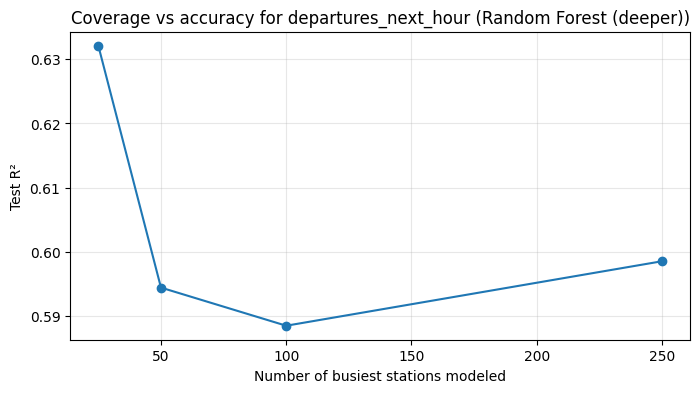

In [11]:
PRIMARY_TARGET = "departures_next_hour"
REGRESSION_MODEL_NAME = "Random Forest (deeper)"

base_feature_cols = [
    "station_key",
    "station_cluster",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "hour_of_day", "day_of_week", "month",
    "is_weekend", "is_holiday", "is_rush_hour", "is_commute_peak", "is_overnight",
    "is_precipitating", "is_raining", "is_snowing", "heavy_precip_flag",
    "departures_lag_1", "departures_lag_2", "departures_lag_24",
    "arrivals_lag_1", "arrivals_lag_2", "arrivals_lag_24",
    "net_flow_lag_1", "net_flow_lag_2", "net_flow_lag_24",
    "total_activity_lag_1", "total_activity_lag_2", "total_activity_lag_24",
    "departures_roll_3", "departures_roll_24",
    "arrivals_roll_3", "arrivals_roll_24",
    "net_flow_roll_3", "net_flow_roll_24",
    "total_activity_roll_3", "total_activity_roll_24",
    "lat", "lng", "capacity", "is_active_station", "utilization_ratio_lag_1",
]
base_feature_cols += [c for c in (feature_df.columns if feature_df is not None else []) if str(c).startswith("weather_pc_")]
base_feature_cols = [c for c in base_feature_cols if feature_df is not None and c in feature_df.columns]

if feature_df is None:
    print("Skipping: feature_df not loaded.")
else:
    sensitivity_rows = []
    for top_n in [25, 50, 100, 250]:
        busy = busiest_station_keys(feature_df, top_n=top_n)
        model_df = feature_df.loc[
            feature_df["station_key"].isin(busy) & feature_df[PRIMARY_TARGET].notna(),
            ["hour", PRIMARY_TARGET] + base_feature_cols,
        ].copy()

        for cat_col in [c for c in ["station_key", "station_cluster"] if c in model_df.columns]:
            model_df[cat_col] = model_df[cat_col].astype("category")

        train_df, valid_df, test_df = chronological_split(model_df)
        _, _, _, valid_metrics, test_metrics, backend = train_rf_regressor(
            train_df, valid_df, test_df, PRIMARY_TARGET, base_feature_cols, model_name=REGRESSION_MODEL_NAME
        )

        sensitivity_rows.append({
            "top_n_stations": top_n,
            "n_rows": len(model_df),
            "backend": backend,
            "valid_rmse": valid_metrics["rmse"],
            "valid_r2": valid_metrics["r2"],
            "test_rmse": test_metrics["rmse"],
            "test_r2": test_metrics["r2"],
        })

    topn_results = pd.DataFrame(sensitivity_rows)
    display(topn_results)

    plt.figure(figsize=(8, 4))
    plt.plot(topn_results["top_n_stations"], topn_results["test_r2"], marker="o")
    plt.title(f"Coverage vs accuracy for {PRIMARY_TARGET} ({REGRESSION_MODEL_NAME})")
    plt.xlabel("Number of busiest stations modeled")
    plt.ylabel("Test R²")
    plt.grid(True, alpha=0.3)
    plt.show()


## 7) Experiment 3 — Feature ablation

This tells you **what is actually doing the work**.

A strong report does not just say “the model performed well.” It says:

- lags alone got us most of the signal,
- calendar/cyclic time added more,
- weather added a smaller but real gain,
- capacity/utilization helped only after the merge was fixed.

This ablation uses the same GPU-aware random-forest helper as the coverage experiment, so it will use the A100 when RAPIDS is active.


,experiment,n_features,backend,valid_rmse,valid_r2,test_rmse,test_r2
0,lags only,20,GPU,10.443509,0.554150,6.727749,0.499236
1,lags + calendar,32,GPU,7.666090,0.759761,6.295873,0.561464
2,lags + calendar + weather,36,GPU,7.579210,0.765175,6.366345,0.551592
3,lags + calendar + weather + spatial,39,GPU,6.848603,0.808266,6.040551,0.596311
4,full,42,GPU,6.841214,0.808679,6.058800,0.593869


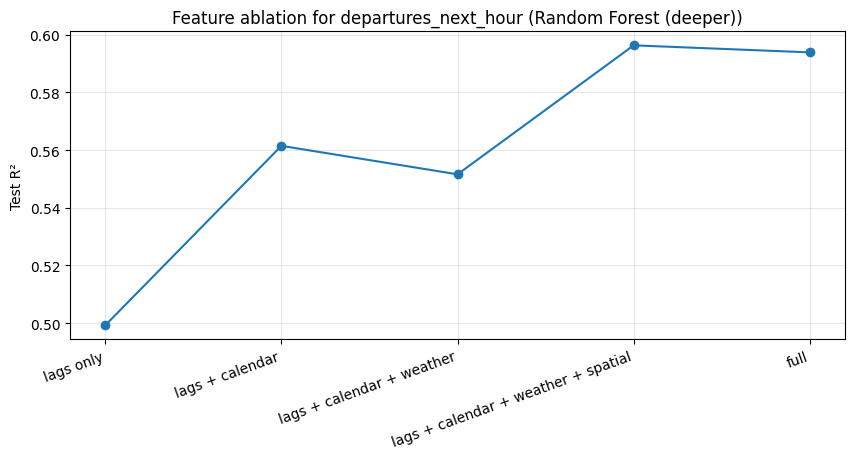

In [12]:
FEATURE_GROUPS = {
    "lags_and_rolls": [
        "departures_lag_1", "departures_lag_2", "departures_lag_24",
        "arrivals_lag_1", "arrivals_lag_2", "arrivals_lag_24",
        "net_flow_lag_1", "net_flow_lag_2", "net_flow_lag_24",
        "total_activity_lag_1", "total_activity_lag_2", "total_activity_lag_24",
        "departures_roll_3", "departures_roll_24",
        "arrivals_roll_3", "arrivals_roll_24",
        "net_flow_roll_3", "net_flow_roll_24",
        "total_activity_roll_3", "total_activity_roll_24",
    ],
    "calendar": [
        "hour_sin", "hour_cos", "dow_sin", "dow_cos",
        "hour_of_day", "day_of_week", "month",
        "is_weekend", "is_holiday", "is_rush_hour", "is_commute_peak", "is_overnight",
    ],
    "weather": [
        "is_precipitating", "is_raining", "is_snowing", "heavy_precip_flag",
    ],
    "spatial_and_station": [
        "station_key", "station_cluster", "lat", "lng",
    ],
    "capacity_related": [
        "capacity", "is_active_station", "utilization_ratio_lag_1",
    ],
}


def available_features(df, cols):
    return [c for c in cols if c in df.columns]


def run_ablation(df, target_col="departures_next_hour", top_n=50, model_name="Random Forest (deeper)"):
    busy = busiest_station_keys(df, top_n=top_n)

    experiment_defs = [
        ("lags only", FEATURE_GROUPS["lags_and_rolls"]),
        ("lags + calendar", FEATURE_GROUPS["lags_and_rolls"] + FEATURE_GROUPS["calendar"]),
        ("lags + calendar + weather", FEATURE_GROUPS["lags_and_rolls"] + FEATURE_GROUPS["calendar"] + FEATURE_GROUPS["weather"]),
        ("lags + calendar + weather + spatial", FEATURE_GROUPS["lags_and_rolls"] + FEATURE_GROUPS["calendar"] + FEATURE_GROUPS["weather"] + FEATURE_GROUPS["spatial_and_station"]),
        ("full", FEATURE_GROUPS["lags_and_rolls"] + FEATURE_GROUPS["calendar"] + FEATURE_GROUPS["weather"] + FEATURE_GROUPS["spatial_and_station"] + FEATURE_GROUPS["capacity_related"]),
    ]

    rows = []
    trained = {}
    for label, features in experiment_defs:
        features = available_features(df, list(dict.fromkeys(features + [c for c in df.columns if str(c).startswith("weather_pc_")])))
        model_df = df.loc[
            df["station_key"].isin(busy) & df[target_col].notna(),
            ["hour", target_col] + features,
        ].copy()

        for cat_col in [c for c in ["station_key", "station_cluster"] if c in model_df.columns]:
            model_df[cat_col] = model_df[cat_col].astype("category")

        train_df, valid_df, test_df = chronological_split(model_df)
        model, valid_pred, test_pred, valid_metrics, test_metrics, backend = train_rf_regressor(
            train_df, valid_df, test_df, target_col, features, model_name=model_name
        )

        rows.append({
            "experiment": label,
            "n_features": len(features),
            "backend": backend,
            "valid_rmse": valid_metrics["rmse"],
            "valid_r2": valid_metrics["r2"],
            "test_rmse": test_metrics["rmse"],
            "test_r2": test_metrics["r2"],
        })
        trained[label] = {
            "model": model,
            "backend": backend,
            "features": features,
            "train_df": train_df,
            "valid_df": valid_df,
            "test_df": test_df,
            "test_pred": test_pred,
        }

    return pd.DataFrame(rows), trained


if feature_df is None:
    print("Skipping: feature_df not loaded.")
else:
    ablation_results, trained_runs = run_ablation(
        feature_df,
        target_col=PRIMARY_TARGET,
        top_n=50,
        model_name=REGRESSION_MODEL_NAME,
    )
    display(ablation_results)

    plt.figure(figsize=(10, 4))
    plt.plot(ablation_results["experiment"], ablation_results["test_r2"], marker="o")
    plt.xticks(rotation=20, ha="right")
    plt.title(f"Feature ablation for {PRIMARY_TARGET} ({REGRESSION_MODEL_NAME})")
    plt.ylabel("Test R²")
    plt.grid(True, alpha=0.3)
    plt.show()



## 8) Experiment 4 — Error slicing

This section answers *where* the model struggles:

- rush hour vs non-rush hour,
- rainy vs dry,
- low-demand vs spike-demand periods,
- different station clusters.

That gives you much stronger discussion material than reporting one average RMSE.


### MAE by `hour_of_day`

,hour_of_day,abs_error
17,17,8.533444
16,16,7.708255
18,18,7.133378
7,7,5.910996
8,8,5.554889
15,15,5.469503
14,14,5.155051
13,13,4.978542
11,11,4.914920
10,10,4.914447


### MAE by `is_precipitating`

,is_precipitating,abs_error
1,1,4.916065
0,0,4.261560


### MAE by `is_weekend`

,is_weekend,abs_error
0,0,4.591487
1,1,3.761236


### MAE by `is_commute_peak`

,is_commute_peak,abs_error
1,1,7.198536
0,0,3.655035


### MAE by `demand_bucket`

,demand_bucket,abs_error
4,very high,5.691560
2,mid,4.830754
3,high,4.251302
1,low,4.211146
0,very low,2.746100


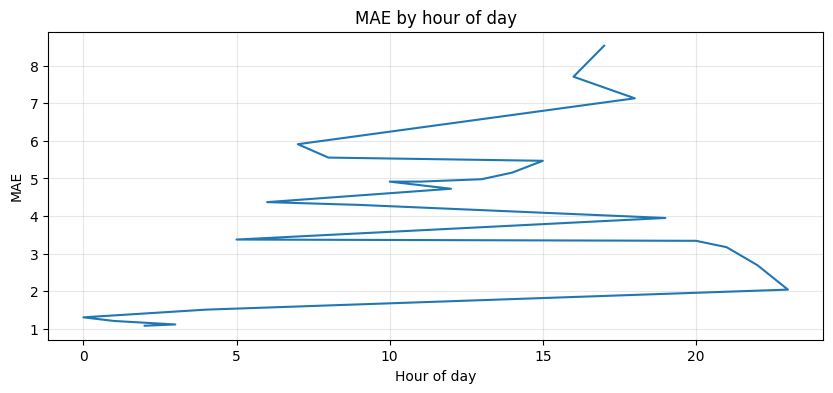

In [13]:

if feature_df is None:
    print("Skipping: feature_df not loaded.")
elif 'trained_runs' not in globals():
    print("Run the ablation cell first.")
else:
    best_label = ablation_results.sort_values("test_r2", ascending=False).iloc[0]["experiment"]
    best_run = trained_runs[best_label]
    test_df = best_run["test_df"].copy()
    test_df["prediction"] = best_run["test_pred"]
    test_df["abs_error"] = (test_df[PRIMARY_TARGET] - test_df["prediction"]).abs()

    if "hour" in test_df.columns:
        test_df["hour_of_day"] = pd.to_datetime(test_df["hour"]).dt.hour
    if PRIMARY_TARGET in test_df.columns:
        test_df["demand_bucket"] = pd.qcut(test_df[PRIMARY_TARGET].rank(method="first"), q=5, labels=["very low", "low", "mid", "high", "very high"])

    slice_tables = {}
    for col in ["hour_of_day", "is_precipitating", "is_weekend", "is_commute_peak", "station_cluster", "demand_bucket"]:
        if col in test_df.columns:
            slice_tables[col] = test_df.groupby(col, as_index=False)["abs_error"].mean().sort_values("abs_error", ascending=False)

    for name, table in slice_tables.items():
        display(Markdown(f"### MAE by `{name}`"))
        display(table.head(20))

    if "hour_of_day" in slice_tables:
        plt.figure(figsize=(10, 4))
        plt.plot(slice_tables["hour_of_day"]["hour_of_day"], slice_tables["hour_of_day"]["abs_error"])
        plt.title("MAE by hour of day")
        plt.xlabel("Hour of day")
        plt.ylabel("MAE")
        plt.grid(True, alpha=0.3)
        plt.show()


## 9) Experiment 5 — Reframe the project as an operational alert task

A practical deployment often does **not** need an exact count. It needs an answer to questions like:

- Will this station be **very busy** next hour?
- Is this station at **shortage risk** next hour?
- Should the system **rebalance** bikes here soon?

This cell creates a high-demand alert target using each station's own 90th percentile, then trains a classifier.
When RAPIDS is active, the classifier path also attempts to use GPU random forest.


In [14]:
def build_high_demand_label(df, target_col="departures_next_hour", quantile=0.90):
    thresholds = df.groupby("station_key", observed=True)[target_col].quantile(quantile)
    out = df.copy()
    out["station_threshold"] = out["station_key"].map(thresholds)

    valid_mask = out[target_col].notna() & out["station_threshold"].notna()
    out["high_demand_next_hour"] = np.nan
    out.loc[valid_mask, "high_demand_next_hour"] = (
        out.loc[valid_mask, target_col] >= out.loc[valid_mask, "station_threshold"]
    ).astype(int)
    out["high_demand_next_hour"] = out["high_demand_next_hour"].astype("float")
    return out, thresholds


def train_rf_classifier(train_df, valid_df, test_df, target_col, feature_cols):
    clf = build_clf_estimator(feature_cols, random_state=42)

    X_train = train_df[feature_cols]
    y_train = train_df[target_col].astype(int)
    X_valid = valid_df[feature_cols]
    y_valid = valid_df[target_col].astype(int)
    X_test = test_df[feature_cols]
    y_test = test_df[target_col].astype(int)

    clf.fit(X_train, y_train)
    valid_prob = clf.predict_proba(X_valid)[:, 1]
    test_prob = clf.predict_proba(X_test)[:, 1]
    valid_pred = (valid_prob >= 0.5).astype(int)
    test_pred = (test_prob >= 0.5).astype(int)

    metrics = pd.DataFrame([
        {
            "split": "validation",
            "backend": "GPU" if getattr(clf, "use_gpu_", False) else "CPU",
            "precision": precision_score(y_valid, valid_pred, zero_division=0),
            "recall": recall_score(y_valid, valid_pred, zero_division=0),
            "f1": f1_score(y_valid, valid_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_valid, valid_prob),
        },
        {
            "split": "test",
            "backend": "GPU" if getattr(clf, "use_gpu_", False) else "CPU",
            "precision": precision_score(y_test, test_pred, zero_division=0),
            "recall": recall_score(y_test, test_pred, zero_division=0),
            "f1": f1_score(y_test, test_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, test_prob),
        },
    ])
    return clf, metrics


if feature_df is None:
    print("Skipping: feature_df not loaded.")
else:
    clf_df, thresholds = build_high_demand_label(feature_df, target_col=PRIMARY_TARGET, quantile=0.90)
    busy = busiest_station_keys(clf_df, top_n=50)
    clf_features = available_features(clf_df, list(dict.fromkeys(
        FEATURE_GROUPS["lags_and_rolls"] + FEATURE_GROUPS["calendar"] + FEATURE_GROUPS["weather"] + FEATURE_GROUPS["spatial_and_station"]
    )))

    model_df = clf_df.loc[
        clf_df["station_key"].isin(busy) & clf_df["high_demand_next_hour"].notna(),
        ["hour", "high_demand_next_hour"] + clf_features,
    ].copy()

    for cat_col in [c for c in ["station_key", "station_cluster"] if c in model_df.columns]:
        model_df[cat_col] = model_df[cat_col].astype("category")

    train_df, valid_df, test_df = chronological_split(model_df)
    _, clf_metrics = train_rf_classifier(train_df, valid_df, test_df, "high_demand_next_hour", clf_features)
    display(clf_metrics)


,split,backend,precision,recall,f1,roc_auc
0,validation,GPU,0.805235,0.560607,0.661014,0.941474
1,test,GPU,0.474192,0.449063,0.461286,0.946351



## 10) Optional bridge back to true availability

Once the capacity merge works, you can create an **availability proxy** by combining:

- station capacity,
- cumulative net flow,
- and a starting-fill assumption.

This is still a proxy, but it is much closer to your original project question.


,station_key,hour,net_flow,capacity,initial_bikes,cumulative_net_flow,bikes_available_proxy,availability_ratio_proxy
0,1234.56,2025-06-18 22:00:00,1,NaN,NaN,1,NaN,NaN
1,1234.56,2025-06-18 23:00:00,0,NaN,NaN,1,NaN,NaN
2,1234.56,2025-06-19 23:00:00,-1,NaN,NaN,0,NaN,NaN
3,1234.56,2025-06-20 09:00:00,0,NaN,NaN,0,NaN,NaN
4,1234.56,2025-06-20 12:00:00,0,NaN,NaN,0,NaN,NaN


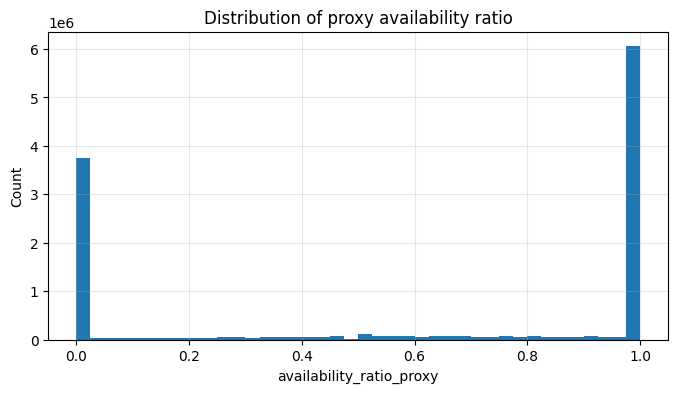

In [15]:

def add_availability_proxy(df, init_fill_ratio=0.50):
    needed = {"station_key", "hour", "net_flow", "capacity"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns for availability proxy: {missing}")

    out = df[["station_key", "hour", "net_flow", "capacity"]].copy()
    out = out.sort_values(["station_key", "hour"]).copy()

    out["capacity"] = pd.to_numeric(out["capacity"], errors="coerce")
    out["initial_bikes"] = out["capacity"] * init_fill_ratio
    out["cumulative_net_flow"] = out.groupby("station_key", observed=True)["net_flow"].cumsum()
    out["bikes_available_proxy"] = (out["initial_bikes"] + out["cumulative_net_flow"]).clip(lower=0)
    out["bikes_available_proxy"] = np.minimum(out["bikes_available_proxy"], out["capacity"])
    out["availability_ratio_proxy"] = out["bikes_available_proxy"] / out["capacity"].replace(0, np.nan)
    return out


if feature_df is None:
    print("Skipping: feature_df not loaded.")
elif "capacity" not in feature_df.columns or feature_df["capacity"].notna().sum() == 0:
    print("Skip for now: capacity is still missing. Fix the capacity join first.")
else:
    availability_proxy = add_availability_proxy(feature_df, init_fill_ratio=0.50)
    display(availability_proxy.head())

    plt.figure(figsize=(8, 4))
    availability_proxy["availability_ratio_proxy"].dropna().hist(bins=40)
    plt.title("Distribution of proxy availability ratio")
    plt.xlabel("availability_ratio_proxy")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.show()



## 11) Recommended project story from here

If I were turning this into the next checkpoint or the final report, I would tell the story in this order:

### What you already accomplished
- You built a station-hour pipeline from Citi Bike trips, weather, and station metadata.
- You showed that **Random Forest** beats linear regression and the naive baseline.
- You showed that **departures** and **arrivals** are predictably better targets than **net flow**.
- You identified that the most important features are **recent activity** and **time-of-day structure**.

### What you learned
- Predicting a difference signal like **net flow** is harder than predicting departures or arrivals directly.
- The current model is strongest on **busy stations**, which is realistic for a first milestone.
- Weather matters, but the biggest predictive lift appears to come from **lags + calendar/time**.

### What must happen next
1. **Fix the capacity merge** so availability-proxy features actually work.
2. **Measure generalization beyond top 50 stations**.
3. **Run feature ablations** to show what helps.
4. **Add an operational target** like high-demand alert or shortage-risk classification.
5. Optionally, **reconstruct proxy availability** once capacity is fixed.

### The strongest final claim you are aiming for
> We can forecast next-hour Citi Bike demand at the busiest stations with good accuracy, identify when/where the model struggles, and extend the pipeline toward an actionable shortage-risk or availability-proxy system for rebalancing decisions.



## 12) My recommended priority order

If you only have time for a few more improvements, do them in this order:

1. **Fix capacity matching**
2. **Run top-N station sensitivity**
3. **Run feature ablation**
4. **Add high-demand classification**
5. **Add proxy availability / shortage risk**

That sequence gives you the biggest report improvement for the least extra work.
